# ParsBERT: Tokenizer + Sentence Embeddings + t-SNE by Topic

This notebook:
1. Loads **ParsBERT** (`HooshvareLab/bert-fa-zwnj-base`) and illustrates its tokenizer on a
   couple of Persian sentences (including ZWNJ compound words like `می‌خواهم`).
2. Computes mean-pooled sentence embeddings with it.
3. Embeds all sentences in `persian_conditionals_bio.jsonl` and reduces them to 2D with t-SNE.
4. Colors the plot by topic, and labels one representative example sentence per topic cluster.

**Note on "topic":** the generation notebook (`generate_conditionals.ipynb`) sampled a random
topic per example when building its prompt, but doesn't save that choice to the output file — so
`persian_conditionals_bio.jsonl` has no ground-truth `topic` field. Rather than regenerating the
whole (API-costly) dataset, this notebook infers a topic per sentence with a cheap zero-shot
trick: embed the same topic phrases used during generation, and assign each sentence to its
nearest topic by cosine similarity in ParsBERT's embedding space.

**Requirements:** `pip install transformers torch scikit-learn matplotlib`
(optionally `pip install arabic-reshaper python-bidi` for correctly shaped Persian text *inside*
the plot — see the "Plot" section).

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

from persian_display import display_persian

c:\Users\lischkaf\micromamba\envs\nlp-fall-school\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load ParsBERT

In [2]:
MODEL_NAME = "HooshvareLab/bert-fa-zwnj-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"Loaded {MODEL_NAME} on {device}, hidden size = {model.config.hidden_size}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9201.42it/s]
[transformers] BertModel LOAD REPORT from: HooshvareLab/bert-fa-zwnj-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Con

Loaded HooshvareLab/bert-fa-zwnj-base on cpu, hidden size = 768


## Tokenizer illustration

ParsBERT's `zwnj` variant is trained to handle the zero-width non-joiner (`\u200c`) used in
compound words like `می‌خواهم` ("I want") correctly, rather than treating it as noise. Below we
tokenize a plain sentence and one with a ZWNJ compound, and look at the resulting subwords and
input ids.

In [3]:
example_sentences = [
    "اگر باران ببارد، فردا به پارک نمی‌رویم.",
    "می\u200cخواهم به مدرسه بروم.",  # explicit ZWNJ compound: می‌خواهم
]

for sent in example_sentences:
    tokens = tokenizer.tokenize(sent)
    encoded = tokenizer(sent, return_tensors="pt")
    display_persian(f"text:   {sent}")
    print("tokens:", tokens)
    print("n_tokens (incl. [CLS]/[SEP]):", encoded["input_ids"].shape[1])
    print()

text:   اگر باران ببارد، فردا به پارک نمیرویم.
tokens: ['اگر', 'باران', 'ببار', '##د', '،', 'فردا', 'به', 'پارک', 'نمیر', '##ویم', '.']
n_tokens (incl. [CLS]/[SEP]): 13

text:   میخواهم به مدرسه بروم.
tokens: ['میخواهم', 'به', 'مدرسه', 'بروم', '.']
n_tokens (incl. [CLS]/[SEP]): 7



## Sentence embeddings via mean pooling

ParsBERT (like base BERT) has no dedicated sentence-embedding head, so we mean-pool the last
hidden state over real (non-padding) tokens, weighted by the attention mask — the standard,
model-agnostic way to turn token embeddings into a single sentence vector for a plain encoder.

In [4]:
@torch.no_grad()
def embed_texts(texts, batch_size=32, max_length=64):
    """Mean-pooled ParsBERT sentence embeddings for a list of texts, shape (len(texts), hidden)."""
    all_embeddings = []
    for start in tqdm(range(0, len(texts), batch_size)):
        batch = texts[start : start + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
        ).to(device)
        output = model(**encoded)
        token_embeddings = output.last_hidden_state  # (batch, seq, hidden)
        mask = encoded["attention_mask"].unsqueeze(-1).float()  # (batch, seq, 1)
        summed = (token_embeddings * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        mean_pooled = summed / counts
        all_embeddings.append(mean_pooled.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0)


# quick check
demo_vecs = embed_texts(example_sentences)
print("embedding shape:", demo_vecs.shape)

100%|██████████| 1/1 [00:00<00:00,  2.36it/s]

embedding shape: (2, 768)


## Load the dataset

In [5]:
DATA_PATH = Path("persian_conditionals_bio.jsonl")

examples = [json.loads(line) for line in DATA_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
texts = [ex["text"] for ex in examples]

print(f"Loaded {len(examples)} examples from {DATA_PATH}")

Loaded 1000 examples from persian_conditionals_bio.jsonl


## Embed all sentences

Set `SAMPLE_SIZE` to a smaller number for a quick run; `None` embeds the whole dataset (a few
minutes on CPU for ~1000 short sentences with `bert-fa-zwnj-base`).

In [6]:
SAMPLE_SIZE = None  # e.g. 300 for a faster run

if SAMPLE_SIZE is not None:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(examples), size=min(SAMPLE_SIZE, len(examples)), replace=False)
    sample_examples = [examples[i] for i in idx]
else:
    sample_examples = examples

sample_texts = [ex["text"] for ex in sample_examples]
sentence_embeddings = embed_texts(sample_texts)
print("sentence_embeddings shape:", sentence_embeddings.shape)

100%|██████████| 32/32 [00:43<00:00,  1.35s/it]

sentence_embeddings shape: (1000, 768)


## Infer a topic per sentence

These are the same 15 topic phrases `generate_conditionals.ipynb` samples from when building its
generation prompts. We embed each phrase, then assign every sentence to its nearest topic by
cosine similarity — a cheap zero-shot proxy for the topic label that wasn't persisted.

In [7]:
# (Persian phrase used for embedding similarity, English gloss used for plot labels)
TOPICS = [
    ("اقتصاد و قیمت‌ها", "Economy & prices"),
    ("آب‌وهوا", "Weather"),
    ("سفر", "Travel"),
    ("تحصیل و دانشگاه", "Education & university"),
    ("خانواده و روابط", "Family & relationships"),
    ("تکنولوژی", "Technology"),
    ("سلامت", "Health"),
    ("ورزش", "Sports"),
    ("محیط زیست", "Environment"),
    ("کار و شغل", "Work & jobs"),
    ("غذا و آشپزی", "Food & cooking"),
    ("ترافیک شهری", "Urban traffic"),
    ("دوستی", "Friendship"),
    ("سیاست", "Politics"),
    ("موسیقی و هنر", "Music & art"),
]
topic_fa = [fa for fa, _en in TOPICS]
topic_en = [en for _fa, en in TOPICS]

topic_embeddings = embed_texts(topic_fa, batch_size=len(topic_fa))


def cosine_similarity_matrix(a, b):
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    return a_norm @ b_norm.T


similarities = cosine_similarity_matrix(sentence_embeddings, topic_embeddings)  # (n_sent, n_topics)
nearest_topic_idx = similarities.argmax(axis=1)
nearest_topic_sim = similarities[np.arange(len(sample_texts)), nearest_topic_idx]
inferred_topics_en = [topic_en[i] for i in nearest_topic_idx]

print("Inferred topic counts:")
for topic, count in Counter(inferred_topics_en).most_common():
    print(f"  {topic:<25} {count}")

100%|██████████| 1/1 [00:00<00:00,  5.23it/s]

Inferred topic counts:
  Economy & prices          155
  Urban traffic             147
  Food & cooking            139
  Weather                   128
  Friendship                83
  Education & university    72
  Music & art               61
  Family & relationships    53
  Sports                    47
  Travel                    46
  Technology                35
  Environment               17
  Health                    10
  Politics                  4
  Work & jobs               3


## t-SNE

In [8]:
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(sample_texts) // 10)),
    random_state=42,
    init="pca",
)
coords_2d = tsne.fit_transform(sentence_embeddings)
print("coords_2d shape:", coords_2d.shape)

coords_2d shape: (1000, 2)


## One representative example per topic

For each topic that appears, we pick the sentence with the highest similarity to that topic's
phrase (its most "typical" example) and print it, alongside its t-SNE coordinates so it can be
cross-checked against the plot below.

In [9]:
representative_idx = {}
for i, topic in enumerate(inferred_topics_en):
    if topic not in representative_idx or nearest_topic_sim[i] > nearest_topic_sim[representative_idx[topic]]:
        representative_idx[topic] = i

print(f"Representative example per topic ({len(representative_idx)} topics present):\n")
for topic in topic_en:
    if topic not in representative_idx:
        continue
    i = representative_idx[topic]
    x, y = coords_2d[i]
    display_persian(f"[{topic}] (sim={nearest_topic_sim[i]:.2f}, xy=({x:.1f}, {y:.1f}))  {sample_texts[i]}")

Representative example per topic (15 topics present):

[Economy & prices] (sim=0.52, xy=(-30.1, -23.3))  نقدینگی مهار شود، فشار افزایشی بر قیمتها کاهش مییابد.
[Weather] (sim=0.53, xy=(12.1, 18.3))  یه کم نمک بریز، غذا خوشطعمتر میشه.
[Travel] (sim=0.58, xy=(-29.0, -6.4))  مدارک سفر را پیشاپیش آماده سازید، سفر بدون دشواری انجام خواهد شد.
[Education & university] (sim=0.56, xy=(-36.3, 2.9))  دانشجو واحدهای پیشنیاز را با موفقیت بگذراند، مجاز به ثبتنام در درسهای تخصصی خواهد شد.
[Family & relationships] (sim=0.52, xy=(-23.9, 33.7))  اگر اعضای خانواده با صداقت به گفتوگو بپردازند، اعتماد متقابل در روابط آنان تقویت میشود.
[Technology] (sim=0.50, xy=(-46.3, 4.2))  اگر تکنولوژیهای نوین بهدرستی ارزیابی شوند، میتوانند بهرهوری سازمانها را افزایش دهند.
[Health] (sim=0.48, xy=(-14.2, 7.4))  با تداوم ورزش، سلامت عمومی بهبود خواهد یافت.
[Sports] (sim=0.53, xy=(-15.3, 9.9))  ورزش را به برنامهٔ روزانه بیفزایید، سلامت عمومیتان بهبود خواهد یافت.
[Environment] (sim=0.47, xy=(32.9, -30.5))  زبالههاتو توی طبیع

## Plot

Note: 15 topics is more categories than a strict CVD-safe categorical palette can guarantee
pairwise-distinguishable in an all-pairs scatter (that safely caps out around 3-4 hues without
secondary encoding). For this exploratory plot we use `tab20`, a qualitative colormap designed for
up to 20 categories, with hues assigned in the fixed topic order above and a legend always shown.
If you need a fully accessible version, facet into small multiples (one panel per topic) instead.

The representative sentence for each topic is annotated directly on its point. matplotlib does not
apply Arabic/Persian glyph shaping or bidi reordering on its own (the same issue as printing raw
Persian text to a non-bidi-aware terminal), so annotations use `arabic_reshaper` + `python-bidi` to
pre-shape the text when those optional packages are installed; otherwise they fall back to the raw
string, which may render with disconnected letters / wrong left-right order.

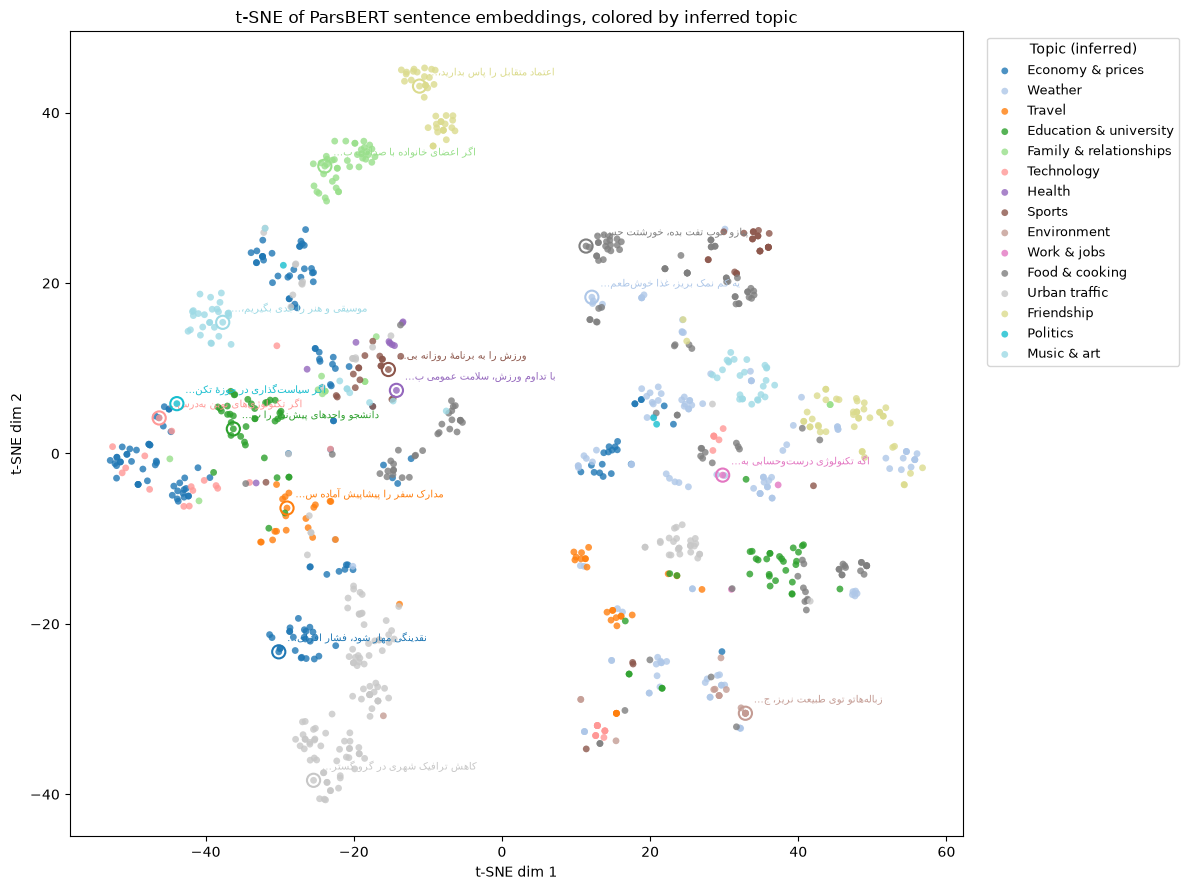

In [10]:
try:
    import arabic_reshaper
    from bidi.algorithm import get_display

    def shape_for_plot(text):
        return get_display(arabic_reshaper.reshape(text))
except ImportError:
    def shape_for_plot(text):
        return text


def truncate(text, max_chars=28):
    return text if len(text) <= max_chars else text[:max_chars].rstrip() + "…"


cmap = plt.get_cmap("tab20")
topic_colors = {topic: cmap(i / max(1, len(topic_en) - 1)) for i, topic in enumerate(topic_en)}

fig, ax = plt.subplots(figsize=(12, 9))
for topic in topic_en:
    mask = np.array(inferred_topics_en) == topic
    if not mask.any():
        continue
    ax.scatter(
        coords_2d[mask, 0],
        coords_2d[mask, 1],
        s=24,
        color=topic_colors[topic],
        label=topic,
        alpha=0.8,
        edgecolors="none",
    )

for topic, i in representative_idx.items():
    x, y = coords_2d[i]
    ax.scatter([x], [y], s=90, facecolors="none", edgecolors=topic_colors[topic], linewidths=1.5, zorder=5)
    label = shape_for_plot(truncate(sample_texts[i]))
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=7,
        color=topic_colors[topic],
        ha="left",
        va="bottom",
    )

ax.set_title("t-SNE of ParsBERT sentence embeddings, colored by inferred topic")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title="Topic (inferred)")
fig.tight_layout()
plt.show()